# P1 잔여 오류 감사
P1은 train-only gene×event-type class-enrichment LR이다. test는 읽지 않는다. seed 42 감사 결과는 후보 선택용이며 새 파라미터 탐색을 하지 않는다.

In [3]:
from pathlib import Path
import subprocess, sys
ROOT=next(p for p in (Path.cwd(),*Path.cwd().parents) if (p/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py').exists())
RUNNER=ROOT/'experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py'; RESULT=RUNNER.parent.parent/'result'
RUN_ID='exp-p1-residual-audit-01'; SEED=42; RUN_EXPERIMENT=True
print({'runner':RUNNER,'result_dir':RESULT,'seed':SEED})

{'runner': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_002/common/run_p1_axis.py'), 'result_dir': PosixPath('/Users/admin/Documents/FinalProject/OZ_fianl_hackaton/experiments/gs/notebooks/exp_model_002/result'), 'seed': 42}


P1 row-local mutation cache: 100%|██████████| 6201/6201 [00:10<00:00, 598.38it/s]


          variant  oof_macro_f1  feature_count  convergence_warning_count  leakage_check  nan_as_mutation_count  runtime_seconds
P1 residual audit      0.494183         4970.6                          0           True                      0        93.022877


,variant,oof_macro_f1,feature_count,convergence_warning_count,leakage_check,nan_as_mutation_count,runtime_seconds
0,P1 residual audit,0.494183,4970.6,0,True,0,93.022877


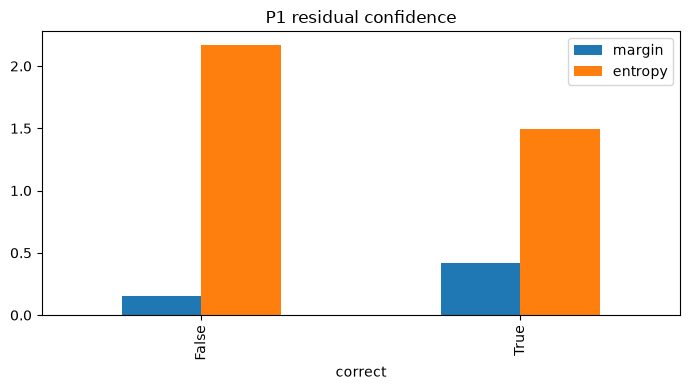

,true_class,predicted_class,count
0,GBMLGG,LGG,120
1,KIPAN,KIRC,106
2,BRCA,OV,69
3,BRCA,PRAD,50
4,LUAD,LUSC,44
5,LGG,GBMLGG,42
6,STES,COAD,42
7,THCA,PCPG,41
8,BRCA,PCPG,41
9,BRCA,SARC,39


In [4]:
if RUN_EXPERIMENT: subprocess.run([sys.executable,str(RUNNER),'--axis','residual','--seed',str(SEED),'--run-id',RUN_ID],check=True)
import pandas as pd, matplotlib.pyplot as plt
s=pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_summary.csv'); display(s)
r=pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_residual_rows.csv'); r.groupby('correct')[['margin','entropy']].mean().plot.bar(figsize=(7,4),title='P1 residual confidence'); plt.tight_layout(); plt.show()
display(pd.read_csv(RESULT/f'{RUN_ID}_seed{SEED}_confusions.csv').head(15))